# ridge 모델 검증 (train_test_split 기반)

(1) 라이브러리 임포트 및 한글 폰트 설정

In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

(2) 데이터 불러오기 및 전처리

In [4]:
folder_path = r"C:\Users\user22\Desktop\아파트 값 예측"
df = pd.read_csv(folder_path + r"\new_city.csv", encoding='utf-8-sig')

# 거래금액 쉼표 제거 후 정수 변환
df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',', '').astype(int)

(3) 도시명 인코딩

In [5]:
# 도시명을 숫자 코드로 변환 (모델 입력용)
df.loc[df['도시명'] == '운정', '도시명_코드'] = 0
df.loc[df['도시명'] == '송도', '도시명_코드'] = 1
df.loc[df['도시명'] == '청라', '도시명_코드'] = 2
df.loc[df['도시명'] == '판교', '도시명_코드'] = 3
df.loc[df['도시명'] == '광교', '도시명_코드'] = 4

(4) 이상치 제거 

In [6]:
print(f"이상치 제거 전 데이터 건수: {len(df)}")

# 전용면적 33㎡ 미만 제거 후 거래금액 기준 z-score > 2인 이상치 제거
df = df[df['전용면적(㎡)'] >= 33]
print(f"전용면적 33㎡ 미만 제거 후: {len(df)}")

mean = df['거래금액(만원)'].mean()
std = df['거래금액(만원)'].std()
z_scores = (df['거래금액(만원)'] - mean) / std
df = df[z_scores.abs() <= 2]
print(f"z-score 이상치 제거 후: {len(df)}")

이상치 제거 전 데이터 건수: 90761
전용면적 33㎡ 미만 제거 후: 90759
z-score 이상치 제거 후: 86200


(5) 독립변수 및 타겟 설정

In [7]:
features = ['건축년도', '전용면적(㎡)', '층', '도시명_코드',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리', '자족용지비율']

df = df.dropna(subset=features + ['거래금액(만원)'])
print(f"결측치 제거 후 데이터 건수: {len(df)}")

X = df[features]
y = df['거래금액(만원)']

결측치 제거 후 데이터 건수: 86200


(6) 훈련/테스트 데이터 분할 및 표준화

In [8]:
# 8:2로 훈련/테스트 분할 후 표준화
train_input, test_input, train_target, test_target = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"훈련 세트 크기: {train_input.shape}")
print(f"테스트 세트 크기: {test_input.shape}")

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

훈련 세트 크기: (68960, 13)
테스트 세트 크기: (17240, 13)


(7) Ridge 모델 학습 및 성능 평가

In [9]:
ridge = Ridge()
ridge.fit(train_scaled, train_target)

print(f"훈련 세트 R²: {ridge.score(train_scaled, train_target):.4f}")
print(f"테스트 세트 R²: {ridge.score(test_scaled, test_target):.4f}")

훈련 세트 R²: 0.7459
테스트 세트 R²: 0.7423


(8) alpha 값에 따른 결정계수 변화 시각화

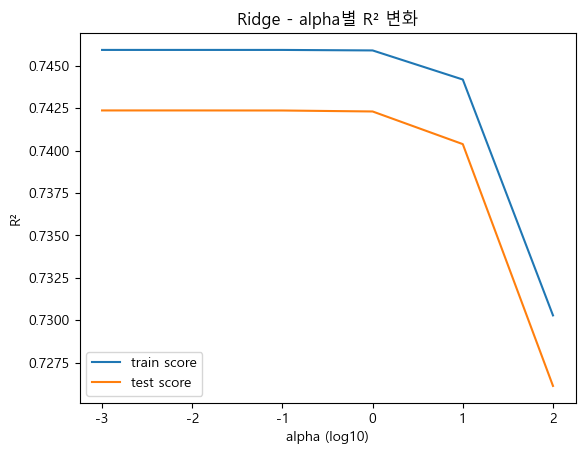

In [10]:
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge_a = Ridge(alpha=alpha)
    ridge_a.fit(train_scaled, train_target)
    train_score.append(ridge_a.score(train_scaled, train_target))
    test_score.append(ridge_a.score(test_scaled, test_target))

plt.plot(np.log10(alpha_list), train_score, label='train score')
plt.plot(np.log10(alpha_list), test_score, label='test score')
plt.xlabel('alpha (log10)')
plt.ylabel('R²')
plt.legend()
plt.title('Ridge - alpha별 R² 변화')
plt.show()

(9) 최적 alpha로 최종 모델 재학습

In [11]:
best_idx = test_score.index(max(test_score))
best_alpha = alpha_list[best_idx]
print(f"최적 alpha: {best_alpha}")

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(train_scaled, train_target)
print(f"최적 alpha 훈련 세트 R²: {ridge_best.score(train_scaled, train_target):.4f}")
print(f"최적 alpha 테스트 세트 R²: {ridge_best.score(test_scaled, test_target):.4f}")

최적 alpha: 0.001
최적 alpha 훈련 세트 R²: 0.7459
최적 alpha 테스트 세트 R²: 0.7424
